**Note**: This notebook has been adapted from the one [here](https://github.com/Featuretools/predict-customer-churn/blob/master/churn/3.%20Feature%20Engineering.ipynb) to remove any dependencies on AWS and S3 so as to just focus on the featuretools functionality without requireming you to make an AWS account and set up the `aws` cli. You should check out the full repo for some other cool notebooks and examples using Spark and Dask.

<a href="https://colab.research.google.com/github/springboard-curriculum/featuretools/blob/master/Feature%20Engineering.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# uncomment and run below to install required libraries if need to
# !pip install featuretools

# Introduction: Automated Feature Engineering with Featuretools (2025 update)

This notebook demonstrates a modern, reproducible workflow for automated feature engineering using Featuretools (v1.30+). All data is loaded from the local `data/` directory. The workflow is compatible with Python 3.10+ and current pandas/dask APIs. Custom primitives and best practices for validation, performance, and reproducibility are included.

In [2]:
# Data science helpers
from pathlib import Path
import pandas as pd
import numpy as np

import featuretools as ft

# Useful for showing multiple outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# make some folders we will need if they do not exist
Path("./data/churn").mkdir(parents=True, exist_ok=True)

In [40]:
# Read in all data from local files (updated for 2025 best practices)
import pandas as pd
import numpy as np
from pathlib import Path

members = pd.read_csv(Path('data/members.csv'),
                      parse_dates=['registration_init_time'],
                      dtype={'gender': 'category'})

trans = pd.read_csv(Path('data/transactions.csv'),
                    parse_dates=['transaction_date', 'membership_expire_date'])

logs = pd.read_csv(Path('data/logs.csv'), parse_dates=['date'])

cutoff_times = pd.read_csv(Path('data/MS-31_labels.csv'), parse_dates=['cutoff_time'])

print(cutoff_times.head())

                                           msno cutoff_time  label  \
0  ++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=  2015-08-01    0.0   
1  ++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=  2015-09-01    0.0   
2  ++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=  2015-10-01    0.0   
3  ++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=  2015-11-01    0.0   
4  ++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=  2015-12-01    0.0   

   days_to_churn churn_date  
0            NaN        NaN  
1            NaN        NaN  
2            NaN        NaN  
3            NaN        NaN  
4            NaN        NaN  


The 3 data tables are represented by the following schema.

![](https://github.com/springboard-curriculum/featuretools/blob/master/images/data_schema.png?raw=1)

This schema is all the domain knowledge needed to perform automated feature engineering in Featuretools.

# Define Entities and EntitySet

The first step in using Featuretools is to make an `EntitySet` and add all the `entitys` - tables - to it. An EntitySet is a data structure that holds the tables and the relationships between them. This makes it easier to keep track of all the data in a problem with multiple relational tables.

In [4]:
import featuretools as ft
import woodwork as ww

# Make entityset
es = ft.EntitySet(id = 'customers')


## Entities

When creating entities from a dataframe, we need to make sure to include:

* The `index` if there is one or a name for the created index. This is a unique identifier for each observation.
* `make_index = True` if there is no index, we need to supply a name under `index` and set this to `True`.
* A `time_index` if present. This is the time at which the information in the row becomes known. Featuretools will use the `time_index` and the `cutoff_time` to make valid features for each label.
* `variable_types`. In some cases our data will have variables for which we should specify the type. An example would be a boolean that is represented as a float. This prevents Featuretools from making features such as the `min` or `max` of a True/False varaibles.

For this problem these are the only arguments we'll need. There are additional arguments that can be used as shown in [the documentation](https://docs.featuretools.com/api_reference.html#entityset-entity-relationship-variable-types).

### Members Table

The `members` table holds basic information about each customer. The important point for this table is to specify that the `city` and `registered_via` columns are discrete, categorical variables and not numerical and that `registration_init_time` is the `time_index`. The `msno` is the unique index identifying each customer.

In [5]:
members.head()

,msno,city,bd,gender,registered_via,registration_init_time
0,8hW4+CV3D1oNM0CIsA39YljsF8M3m7g1LAX6AQd3C8I=,4,24,male,3,2014-11-04
1,yhcODfebyTYezE6KAPklcV1us9zdOYJ+7eHS7f/xgoU=,8,37,male,9,2007-02-11
2,sBlgSL0AIq49XsmBQ2KceKZNUyIxT1BwSkN/xYQLGMc=,15,21,male,3,2013-02-08
3,Xy3Au8sZKlEeHBQ+C7ro8Ni3X/dxgrtmx0Tt+jqM1zY=,1,0,NaN,9,2015-02-01
4,NiCu2GVWgT5QZbI85oYRBEDqHUZbzz2azS48jvM+khg=,12,21,male,3,2015-02-12


In [6]:
# check "msno" is unique

members['msno'].is_unique

True

In [15]:
# Try to convert to datetime, invalid parsing will be set as NaT
invalid_dates = pd.to_datetime(members['registration_init_time'], errors='coerce').isna()

# Show rows with invalid dates
members[invalid_dates]

,msno,city,bd,gender,registered_via,registration_init_time


In [16]:
# Try parsing with a specific format to see if any fail
invalid_specific = pd.to_datetime(members['registration_init_time'], format='%Y-%m-%d', errors='coerce').isna()
print(members[invalid_specific])

Empty DataFrame
Columns: [msno, city, bd, gender, registered_via, registration_init_time]
Index: []


In [8]:
# Add the dataframe to the EntitySet with proper logical types (Featuretools >=1.0.0 API)
import featuretools as ft
import woodwork as ww

es = ft.EntitySet(id='customers')
es.add_dataframe(
    dataframe_name='members',
    dataframe=members,
    index='msno',
    time_index='registration_init_time',
    logical_types={'city': 'Categorical', 'registered_via': 'Categorical'}
)
es

/Users/Allison/Code/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
  Relationships:
    No relationships

Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
  Relationships:
    No relationships

### Transactions Table

The transactions table contains payments made by the customers. Each row records one payment.

In [9]:
trans.head()

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,5F7G3pHKf5ijGQpoKuko0G7Jm3Bde6ktfPKBZySWoDI=,41,30,99,99,1,2017-02-10,2017-03-10,0
1,DQMPoCSc6EB39ytgnKCRsUIZnR6ZWSrHeDmX7nbxAKs=,41,30,149,149,1,2016-02-01,2016-03-02,0
2,Lrais3nsgqYwpfpSoyK3fHuPutf6cloTI5T5dQfs4lA=,38,30,149,149,0,2016-02-23,2016-04-23,0
3,ZPOjgxQw1/J7v5xgBJTCLXWuwq5Xmk33nO6AoUO1+mY=,41,30,149,119,1,2015-09-06,2016-08-01,0
4,MvR23u4bIiWM+U+VE1Mvw3qqdj/0Ixs1sf7avavjhRs=,38,30,149,149,0,2016-10-28,2016-11-27,0


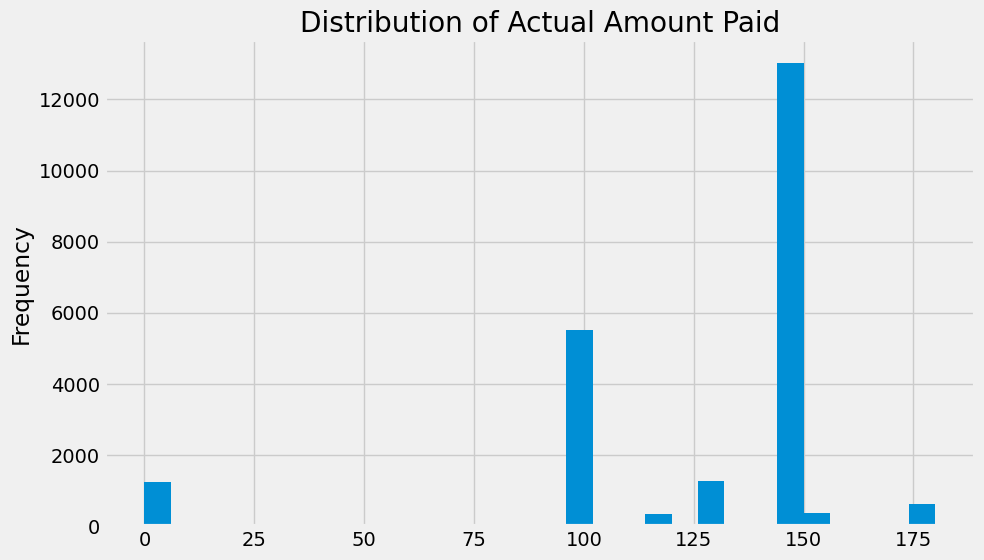

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (10, 6)

trans.loc[trans['actual_amount_paid'] < 250, 'actual_amount_paid'].dropna().plot.hist(bins = 30);
plt.title('Distribution of Actual Amount Paid');

#### Domain Knowledge Features (2025 best practice)

Before creating the entity from this dataframe, we can create a few new variables based on domain knowledge. These hand-crafted features are created before adding the table to the EntitySet, so Featuretools can stack primitives on top of them. This is a recommended practice for combining human insight with automated feature engineering.

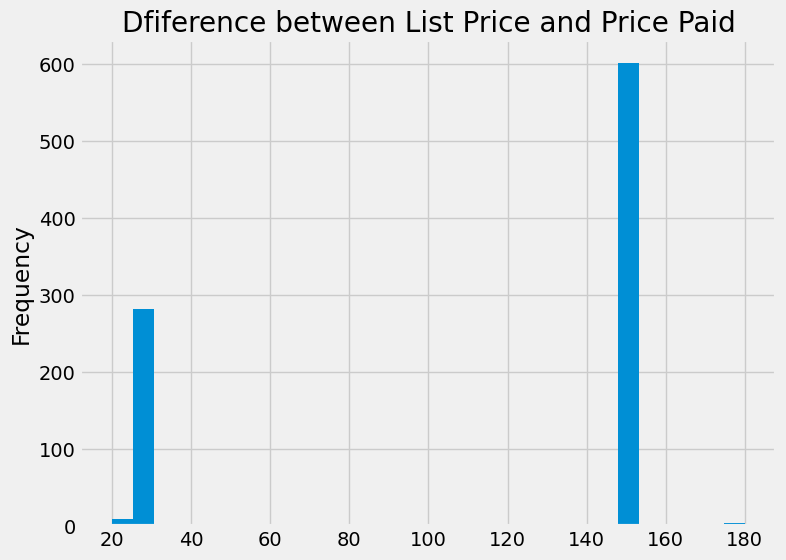

In [11]:
# Difference between listing price and price paid
trans['price_difference'] = trans['plan_list_price'] - trans['actual_amount_paid']

# Planned price per day
trans['planned_daily_price'] = trans['plan_list_price'] / trans['payment_plan_days']

# Actual price per day
trans['daily_price'] = trans['actual_amount_paid'] / trans['payment_plan_days']

trans.loc[trans['price_difference'] > 0, 'price_difference'].plot.hist(bins = 30,
                                                                       figsize = (8, 6));
plt.title('Dfiference between List Price and Price Paid');

There is no `index` in this dataframe so we have to specify to make an index and pass in a name. There is a `time_index`, the time of the transaction, which will be critical when filtering data based on cutoff times to make features. Again, we also need to specify several variable types.

There is one slight anomaly with the transactions where some membership expire dates are after the transactions date, so we will filter those out.

In [12]:
# Filter anomalies
trans = trans[trans['membership_expire_date'] > trans['transaction_date']]

In [14]:
# Add the transactions dataframe to the EntitySet (Featuretools >=1.0.0 API)
es.add_dataframe(
    dataframe_name='transactions',
    dataframe=trans,
    index='transactions_index',
    make_index=True,
    time_index='transaction_date',
    logical_types={
        'payment_method_id': 'Categorical',
        'is_auto_renew': 'Boolean',
        'is_cancel': 'Boolean'
    }
)
es

/Users/Allison/Code/.venv/lib/python3.11/site-packages/featuretools/entityset/entityset.py:724: UserWarning: A Woodwork-initialized DataFrame was provided, so the following parameters were ignored: index, time_index, logical_types, make_index
  warnings.warn(


Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
  Relationships:
    No relationships

Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
  Relationships:
    No relationships

In [17]:
es


Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
  Relationships:
    No relationships

### Logs

The `logs` contain user listening behavior. As before we'll make a few domain knowledge columns before adding to the `EntitySet`.

In [19]:
logs.head()

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs,total,percent_100,percent_unique,seconds_per_song
0,6+/V1NwBbqjBOCvRSDueeJZ58F4DY7h7fG6fSZtHaAE=,2017-03-04,29,28,18,11,111,79,34727.142,197,0.563452,0.401015,176.279909
1,E2aBGFTKR6jzp+1knh7JOOF39gLuu+CoZMWaAL/DA0M=,2017-03-27,1,0,2,0,184,173,33408.719,187,0.983957,0.925134,178.656251
2,g7exJzakJlHXwzUydnShY5w24WXSwJyS6QqgoFeyr7g=,2017-03-15,0,0,0,0,21,21,4951.000,21,1.000000,1.000000,235.761905
3,X+i9OmM3P42cETt5gPkOnz8vXGViQL5/M/NMiMQ+Olc=,2017-03-13,3,1,0,0,33,27,8755.599,37,0.891892,0.729730,236.637811
4,tbl8blAVl6j4A8zW1Gnyg78Hc0LAQzzcYesmzgJ7ofs=,2017-03-27,6,5,0,0,2,6,1035.853,13,0.153846,0.461538,79.681000


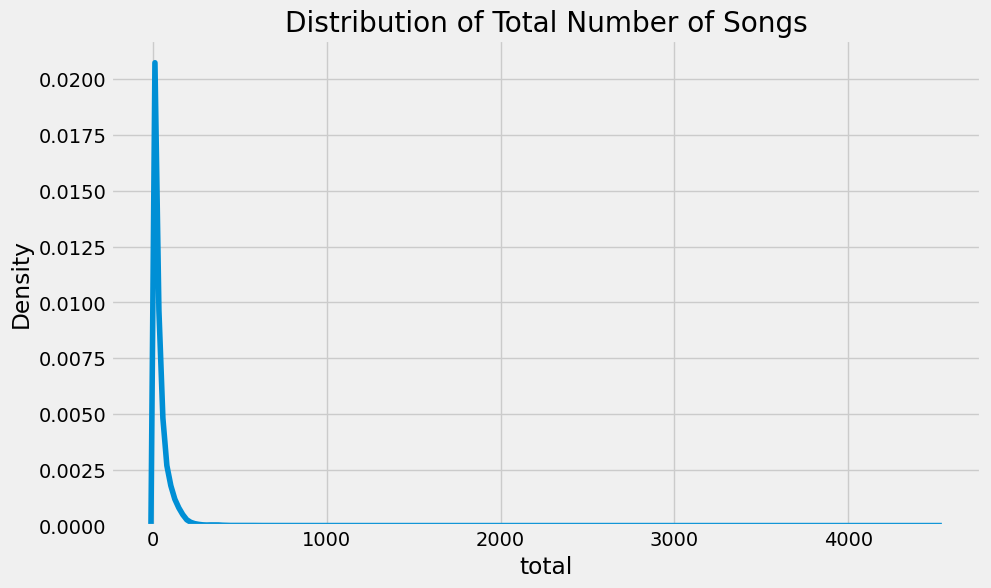

In [18]:
# Make a few features by hand
logs['total'] = logs[['num_25', 'num_50', 'num_75', 'num_985', 'num_100']].sum(axis = 1)
logs['percent_100'] = logs['num_100'] / logs['total']
logs['percent_unique'] = logs['num_unq'] / logs['total']
logs['seconds_per_song'] = logs['total_secs'] / logs['total']

import seaborn as sns

sns.kdeplot(logs['total']);
plt.title('Distribution of Total Number of Songs');

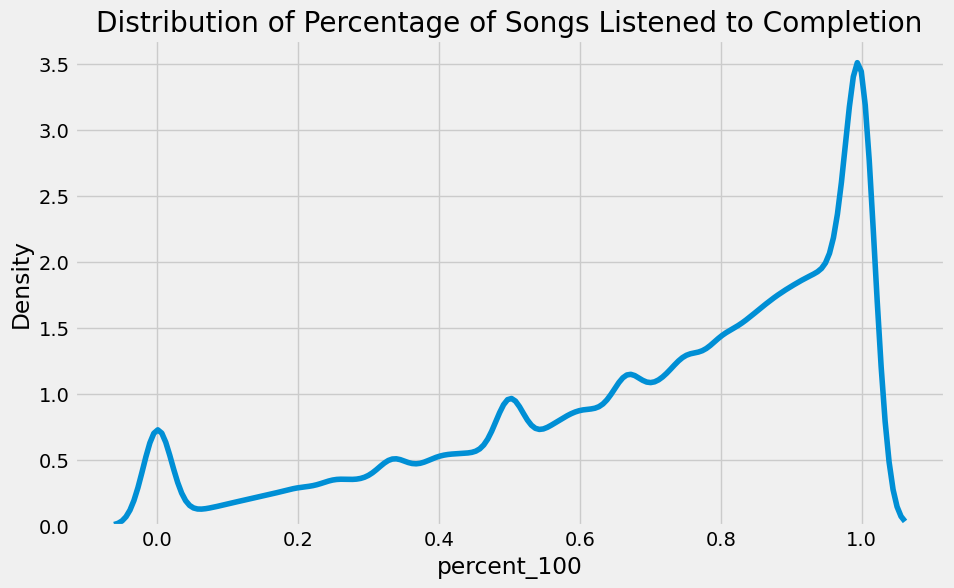

In [ ]:
sns.kdeplot(logs['percent_100']);
plt.title('Distribution of Percentage of Songs Listened to Completion');

There is `time_index` in the logs although no `index` present.

In [20]:
# Add logs dataframe to the EntitySet (Featuretools >=1.0.0 API)
es.add_dataframe(
    dataframe_name='logs',
    dataframe=logs,
    index='logs_index',
    make_index=True,
    time_index='date'
)
es

/Users/Allison/Code/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
    logs [Rows: 424252, Columns: 14]
  Relationships:
    No relationships

Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
    logs [Rows: 424252, Columns: 14]
  Relationships:
    No relationships

Making features by hand may seem counterintuitive if we are using automated feature engineering, but the benefits of doing this before using Featuretools is that these features can be stacked on top of to build deep features. Automated feature engineering will therefore take our existing hand-built features and extract more value from them by combining them with other features.

Another method to improve the power of deep feature synthesis is through interesting values, which specify conditional statements used to build features.

### Interesting Values

In order to create conditional features, we can set interesting values for existing columns in the data. The following code will be used to build features conditional on the value of `is_cancel` and `is_auto_renew` in the transactions data. The primitives used for the conditional features are specified as `where_primitives` in the call to Deep Feature Synthesis. For example, if we used a `mean` primitive along with the following interesting values, we will get a mean of transactions where the transaction was cancelled, as well as the mean of transactions where the transaction was not cancelled.

In [21]:
es['transactions']['is_cancel'].interesting_values = [0, 1]
es['transactions']['is_auto_renew'].interesting_values = [0, 1]

# Relationships

Table relationships should be familiar to anyone who has worked with relational databases and the idea is the same in Featuretools. We use relationships to specify how examples in one table relate to examples in other tables. The entityset structure for this problem is fairly simple as there are only three entities with two relationships.  `members` is the parent of `logs` and `transactions`. In both relationships, the parent and child variable is `msno`, the customer id.

The two relationships are: one linking `members` to `transactions` and one linking `members` to `logs`. The order for relationships in featuretools is parent variable, child variable.

In [22]:
print(es)

Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
    logs [Rows: 424252, Columns: 14]
  Relationships:
    No relationships


In [23]:
es.add_dataframe(
    dataframe_name='members',
    dataframe=members,
    index='msno',
    time_index='registration_init_time',
    logical_types={'msno': 'Categorical', 'city': 'Categorical', 'registered_via': 'Categorical'}
)# Define the relationships explicitly with the EntitySet (Featuretools >=1.0.0 API)
es.add_relationship(
    parent_dataframe_name='members',
    parent_column_name='msno',
    child_dataframe_name='transactions',
    child_column_name='msno'
)
es.add_relationship(
    parent_dataframe_name='members',
    parent_column_name='msno',
    child_dataframe_name='logs',
    child_column_name='msno'
)
es

/Users/Allison/Code/.venv/lib/python3.11/site-packages/featuretools/entityset/entityset.py:393: UserWarning: Logical type Categorical for child column msno does not match parent column msno logical type Unknown. Changing child logical type to match parent.
  warnings.warn(


Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
    logs [Rows: 424252, Columns: 14]
  Relationships:
    transactions.msno -> members.msno

/Users/Allison/Code/.venv/lib/python3.11/site-packages/featuretools/entityset/entityset.py:393: UserWarning: Logical type Categorical for child column msno does not match parent column msno logical type Unknown. Changing child logical type to match parent.
  warnings.warn(


Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
    logs [Rows: 424252, Columns: 14]
  Relationships:
    transactions.msno -> members.msno
    logs.msno -> members.msno

Entityset: customers
  DataFrames:
    members [Rows: 6658, Columns: 6]
    transactions [Rows: 22329, Columns: 13]
    logs [Rows: 424252, Columns: 14]
  Relationships:
    transactions.msno -> members.msno
    logs.msno -> members.msno

### Cutoff Times

`cutoff_times` are a critical piece of any time based machine learning problem. The label times dataframe has columns of member id, cutoff time, and label. __For each cutoff time, only data from before the cutoff time can be used to build features for that label.__ This is one of the greatest advantages of Featuretools compared to manual feature engineering: __Featuretools automatically filters our data based on the cutoff times to ensure that all the features are valid for machine learning.__ Normally, we would have to take extreme care to make sure all of our features are valid, but Featreutools is able to implement the filtering logic behind the scenes for us.

All we have to do is make sure to pass in the correct label times for the prediction problem we want to solve.

In [24]:
cutoff_times = cutoff_times.drop_duplicates(subset = ['msno', 'cutoff_time'])
cutoff_times.head()

,msno,cutoff_time,label,days_to_churn,churn_date
0,++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=,2015-08-01,0.0,NaN,NaN
1,++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=,2015-09-01,0.0,NaN,NaN
2,++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=,2015-10-01,0.0,NaN,NaN
3,++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=,2015-11-01,0.0,NaN,NaN
4,++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE=,2015-12-01,0.0,NaN,NaN


# Deep Feature Synthesis

With the entities and relationships fully defined, we are ready to run [Deep Feature Synthesis (DFS)](https://www.featurelabs.com/blog/deep-feature-synthesis/). This process applies feature engineering building blocks called [feature primitives](https://docs.featuretools.com/automated_feature_engineering/primitives.html) to a dataset to build hundreds of features. Feature primitives are basic operations of two types - transforms and aggregations - that stack to build deep features (for more information see the previous linked resources). These includes many operations that we would traditionally carry out by hand, but automated feature engineering saves us from having to implement these features one at a time.

The call to `ft.dfs` needs the entityset which holds all the tables and relationships between them, the `target_entity` to make features for, the specific primitives, the maximum stacking of primitives (`max_depth`), the `cutoff_times`, and a number of optional parameters.

To start, we'll use the default aggregation and transformation primitives as well as two `where_primitives` and see how many features this generates. To only generate the definitions of the features, we pass in `features_only = True`.

For full details on Deep Feature Synthesis, take a look at [the documentation](https://docs.featuretools.com/api_reference.html#deep-feature-synthesis).

In [25]:
# Run Deep Feature Synthesis (DFS) with updated API
feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name='members',
    cutoff_time=cutoff_times,
    where_primitives=['sum', 'mean'],
    max_depth=2,
    features_only=True
)

/Users/Allison/Code/.venv/lib/python3.11/site-packages/featuretools/synthesis/dfs.py:321: UnusedPrimitiveWarning: Some specified primitives were not used during DFS:
  where_primitives: ['mean', 'sum']
This may be caused by a using a value of max_depth that is too small, not setting interesting values, or it may indicate no compatible columns for the primitive were found in the data. If the DFS call contained multiple instances of a primitive in the list above, none of them were used.
  warnings.warn(warning_msg, UnusedPrimitiveWarning)


In [28]:
feature_defs[:5]

[<Feature: city>,
 <Feature: bd>,
 <Feature: gender>,
 <Feature: registered_via>,
 <Feature: COUNT(transactions)>]

In [26]:
print(f'This will generate {len(feature_defs)} features.')

This will generate 140 features.


In [27]:
import random; random.seed(42)

random.sample(feature_defs, 10)

[<Feature: SKEW(transactions.daily_price)>,
 <Feature: MAX(transactions.daily_price)>,
 <Feature: MIN(logs.num_50)>,
 <Feature: MEAN(logs.num_unq)>,
 <Feature: MEAN(logs.num_100)>,
 <Feature: STD(transactions.payment_plan_days)>,
 <Feature: PERCENT_TRUE(transactions.is_cancel)>,
 <Feature: NUM_UNIQUE(logs.YEAR(date))>,
 <Feature: MIN(transactions.price_difference)>,
 <Feature: SUM(logs.percent_unique)>]

We can see that Featuretools has built almost 200 features automatically for us using the table relationships and feature primitives. If built by hand, each of these features would require minutes of work, totaling many hours to build 188 features. Moreover, although the features are not necessarily intuitive, they are easy to explain in natural language because they are simple operations stacked on top of each other.

## Specify Primitives

Now we'll do a call to `ft.dfs` specifying the primitives to use. Often, these will depend on the problem and can involve domain knowledge. The best way to choose primitives is by trying out a variety and seeing which perform the best. Like many operations in machine learning, choosing primitives is still largely an empirical, rather than theoretical, practice.

### Aggregation Primitives

In [30]:
all_p = ft.list_primitives()
print(all_p.head())

trans_p = all_p.loc[all_p['type'] == 'transform'].copy()
print(trans_p.head())

agg_p = all_p.loc[all_p['type'] == 'aggregation'].copy()
print(agg_p.head())

pd.options.display.max_colwidth = 100
agg_p.head()

                          name         type  \
0         max_consecutive_true  aggregation   
1  is_monotonically_increasing  aggregation   
2    num_consecutive_less_mean  aggregation   
3               n_unique_weeks  aggregation   
4                    num_peaks  aggregation   

                                                             description  \
0  Determines the maximum number of consecutive True values in the input   
1                    Determines if a series is monotonically increasing.   
2       Determines the length of the longest subsequence below the mean.   
3                                 Determines the number of unique weeks.   
4                   Determines the number of peaks in a list of numbers.   

                                   valid_inputs  \
0       <ColumnSchema (Logical Type = Boolean)>   
1  <ColumnSchema (Semantic Tags = ['numeric'])>   
2  <ColumnSchema (Semantic Tags = ['numeric'])>   
3      <ColumnSchema (Logical Type = Datetime)>   
4  <C

,name,type,description,valid_inputs,return_type
0,max_consecutive_true,aggregation,Determines the maximum number of consecutive True values in the input,<ColumnSchema (Logical Type = Boolean)>,<ColumnSchema (Logical Type = Integer) (Semantic Tags = ['numeric'])>
1,is_monotonically_increasing,aggregation,Determines if a series is monotonically increasing.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = BooleanNullable)>
2,num_consecutive_less_mean,aggregation,Determines the length of the longest subsequence below the mean.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>
3,n_unique_weeks,aggregation,Determines the number of unique weeks.,<ColumnSchema (Logical Type = Datetime)>,<ColumnSchema (Logical Type = Integer) (Semantic Tags = ['numeric'])>
4,num_peaks,aggregation,Determines the number of peaks in a list of numbers.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = Integer) (Semantic Tags = ['numeric'])>


In [32]:
# Specify aggregation primitives
agg_primitives = ['sum', 'time_since_last', 'avg_time_between', 'all', 'mode', 'num_unique', 'min', 'last',
                  'mean', 'percent_true', 'max', 'std', 'count']


list

## Transform Primitives

In [33]:
trans_p.tail()

,name,type,description,valid_inputs,return_type
198,cumulative_time_since_last_false,transform,Determines the time since last `False` value.,"<ColumnSchema (Logical Type = Datetime) (Semantic Tags = ['time_index'])>, <ColumnSchema (Logica...",<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
199,modulo_numeric_scalar,transform,Computes the modulo of each element in the list by a given scalar.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Semantic Tags = ['numeric'])>
200,is_leap_year,transform,Determines the is_leap_year attribute of a datetime column.,<ColumnSchema (Logical Type = Datetime)>,<ColumnSchema (Logical Type = BooleanNullable)>
201,quarter,transform,"Determines the quarter a datetime column falls into (1, 2, 3, 4)",<ColumnSchema (Logical Type = Datetime)>,"<ColumnSchema (Logical Type = Ordinal: [1, 2, 3, 4]) (Semantic Tags = ['category'])>"
202,haversine,transform,Calculates the approximate haversine distance between two LatLong columns.,<ColumnSchema (Logical Type = LatLong)>,<ColumnSchema (Semantic Tags = ['numeric'])>


In [34]:
# Specify transformation primitives
trans_primitives = ['weekday', 'cum_sum', 'day', 'month', 'diff', 'time_since_previous']

### Where Primitives

These primitives are applied to the `interesting_values` to build conditional features.

In [35]:
# Specify where primitives
where_primitives = ['sum', 'mean', 'percent_true', 'all', 'any']

## Custom Primitives (2025 best practice)

Custom primitives allow you to encode domain knowledge as reusable feature engineering operations. Define them as Python classes inheriting from `AggregationPrimitive` or `TransformPrimitive`. Register them with Featuretools and include them in your DFS call. See the example below for a modern implementation.

In [ ]:
# Example of a modern custom primitive (2025 best practice)
import featuretools as ft
from featuretools.primitives import AggregationPrimitive
from woodwork.column_schema import ColumnSchema
from woodwork.logical_types import Double, Datetime
import pandas as pd

# Define new custom aggregation primitive for FeatureTools by subclassing Aggregation Primitive
class TotalPreviousMonth(AggregationPrimitive):
    """Return total of `numeric` column in the month prior to `time`."""
    name = "total_previous_month" # Set name of primitive as it will appear in Featuretools
    input_types = [ColumnSchema(logical_type=Double), ColumnSchema (logical_type=Datetime)] # Specify that primitive takes two columns as input: a numeric (Double) and datetime column
    return_type = ColumnSchema(logical_type=Double) # output will be numeric
    uses_calc_time = True # indicates that primitive uses cutoff time for its computation

    def get_function(self): # Define a method that returns function implementing primitive's logic
        def total_previous_month(numeric, datetime, calc_time=None): # Compute total for previous month with optional cutoff time
            df = pd.DataFrame({'value': numeric, 'date': datetime}) # Create dataframe from input columns
            df['date'] = pd.to_datetime(df['date']) # Ensure date column is in datetime format
            if calc_time is not None: # Check is cutoff time is provided
                current_time = pd.to_datetime(calc_time) # If true set current_time to cutoff time
            else:
                current_time = df['date'].max() # If false, set current_time to latest date
            previous_month = current_time.month - 1 # Get previous month number
            year = current_time.year # Get current year
            if previous_month == 0: # If current month is January, previous month becomes 0 but there is no month 0, so converted to 12 (December) in the following step and then decrement year by 1.
                previous_month = 12 # Set previous_month to December and
                year = current_time.year - 1 # Set year to previous year
            df = df[(df['date'].dt.month == previous_month) & (df['date'].dt. year == year)] # Filter dataframe to only rows from previous month and year
            total = df['value'].sum() # Sum values from previous month and year
            return total
        return total_previous_month

In [41]:
#-------------Test Custom Primitive-------------
# Generate sample data
numeric = [10, 12, 14, 15, 19, 22, 9, 8, 8, 11] # Create list of numbers
dates = pd.date_range('2018-01-01', '2018-03-01', periods = len(numeric)) # Create evenly spaced dates between 1/1/18 and 3/1/0218. Number of dates = length of numeric list, i.e., 10

pd.DataFrame({'value': numeric, 'date': dates}).head(6) # Create dataframe from sample data and display dataframe

# Instantiate the custom aggregation primitive, i.e., create instance of custum Featuretools aggregation primitive class
primitive = TotalPreviousMonth()

# Get the function from the custom primitive--retrieve function that implements the logic for the custom primitive
total_func = primitive.get_function()

# Test it with sample data
print(total_func(numeric, dates))

,value,date
0,10,2018-01-01 00:00:00
1,12,2018-01-07 13:20:00
2,14,2018-01-14 02:40:00
3,15,2018-01-20 16:00:00
4,19,2018-01-27 05:20:00
5,22,2018-02-02 18:40:00


47


In [ ]:
# ---------Test Custom Primitive using different input data---------
# Generate sample data
numeric = [10, 12, 14, 5, 7, 8]
dates = pd.date_range('2018-01-01', '2018-03-01', periods = len(numeric))
pd.DataFrame({'value': numeric, 'date': dates}).head(6)

# Instantiate the custom aggregation primitive
primitive = TotalPreviousMonth()

# Get the function from the custom primitive
total_func = primitive.get_function()

# Test it with sample data
print(total_func(numeric, dates))

,value,date
0,10,2018-01-01 00:00:00
1,12,2018-01-12 19:12:00
2,14,2018-01-24 14:24:00
3,5,2018-02-05 09:36:00
4,7,2018-02-17 04:48:00
5,8,2018-03-01 00:00:00


12


### Custom Primitive Implementation

Making a custom primitive is simple: first we define a function (`total_previous_month`) and then we `make_agg_primitive` with `input_type[s]`, a `return_type`, and whether or not the primitive requires the `cutoff_time` through `uses_calc_time`.

This primitive is an aggregation primitive because it takes in multiple numbers - transactions for the previous month - and returns a single number - the total of the transactions.

Now we just have to pass this in as another aggregation primitive for Featuretools to use it in calculations.

The second custom primitive finds the time since a previous true value. This is originally intended for the `is_cancel` variable in the `transactions` dataframe, but it can work for any Boolean variable. It simply finds the time between True examples.

In [ ]:
# Define function that takes boolean and datetime sequences
def time_since_true(boolean, datetime):
    """Calculate time since previous true value"""
    if np.any(np.array(list(boolean)) == 1): # Check if there are any true values in boolean sequence
        # If True, create dataframe with boolean and datetime, sort from oldest to newest date, and reset index
        df = pd.DataFrame({'value': boolean, 'date': datetime}).\
                sort_values('date', ascending = False).reset_index()

        older_date = None # Initialize variable to hold previous true date

        # Iterate through each date in reverse order
        for date in df.loc[df['value'] == 1, 'date']:

            # Check if older_date = None. If True, means the current True is the first one in the sequence
            if older_date == None:
                # Get indices of rows where date is on or after current true date
                times_after_idx = df.loc[df['date'] >= date].index 

            else:
                # # Select rows for dates that fall between the current true event and the previous true event, including the current date but excluding the older one.
                times_after_idx = df.loc[(df['date'] >= date) & (df['date'] < older_date)].index
            # Update older_date to current date in the loop for next iteration    
            older_date = date
            # Create 'time_since_previous' on-the-fly and calculate time diffs for selected rows and convert each diff into total number of seconds.
            df.loc[times_after_idx, 'time_since_previous'] = (df.loc[times_after_idx, 'date'] - date).dt.total_seconds()

        return list(df['time_since_previous'])[::-1] # Return values in the 'time_since_previous' column as a Python list in reverse order. The [::-1] slice reverses the list, so the output is the time differences for each row, starting from the last row and ending with the first.

    # Handle case with no true values
    else:
        return [np.nan for _ in range(len(boolean))]

In [45]:
# Test the function with empty data
booleans = []
dates = []
df = pd.DataFrame({'value': booleans, 'date': dates})
time_since_true(df['value'], df['date'])

[]

In [46]:
# Test the function with multiple True values. Show how it handles multiple true events and resets timer after each one.
booleans = [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0]
dates = pd.date_range('2018-01-01', '2018-03-01', periods = len(booleans))
df = pd.DataFrame({'value': booleans, 'date': dates})
time_since_true(df['value'], df['date'])

[0.0,
 509760.0,
 1019520.0,
 1529280.0,
 2039040.0,
 0.0,
 0.0,
 0.0,
 509760.0,
 1019520.0,
 1529280.0]

In [ ]:
# Test the function with sample data with only one True at the start.
booleans = [1, 0, 0]
dates = pd.date_range('2018-01-01', '2018-03-01', periods = len(booleans))
time_since_true(booleans, dates)

[0.0, 2548800.0, 5097600.0]

In [ ]:
# Test function with no true values. 
booleans = [0, 0]
dates = pd.date_range('2018-01-01', '2018-03-01', periods = len(booleans))
time_since_true(booleans, dates)

[nan, nan]

This is a transformation primitive since it acts on multiple columns in the same table. The returned list is the same length as the original column.

In [ ]:
import featuretools as ft
from featuretools.primitives import TransformPrimitive
from woodwork.column_schema import ColumnSchema
from woodwork.logical_types import Boolean, Datetime, Double
import pandas as pd

# Define the custom transformation primitive
class TimeSinceTrue(TransformPrimitive):
    """Returns the time (in seconds) since the previous True in a boolean column for each row."""
    name = "time_since_true"
    input_types = [ColumnSchema(logical_type=Boolean), ColumnSchema(logical_type=Datetime)]
    return_type = ColumnSchema(logical_type=Double)

    def get_function(self):
        def time_since_true(boolean, datetime):
            if len(boolean) == 0:
                return []

            if np.any(np.array(list(boolean)) == 1):
                df = pd.DataFrame({'value': boolean, 'date': datetime}).sort_values('date', ascending = True).reset_index()
                older_date = None
                for date in df.loc[df['value'] == 1, 'date']: # Iterate over all dates in the 'date' column where the corresponding 'value' is True
                    if older_date is None: # Check if older_date is None (i.e., this is the first True encountered)
                            times_after_idx = df.loc[df['date'] >= date].index # Select all rows with dates on or after the current True date
                    else:
                        times_after_idx = df.loc[(df['date'] >= date) & (df['date'] < older_date)].index # Select rows for dates from the current true event (inclusive) to the previous true event (exclusive).
                    older_date = date # Update older_date to current date for next iteration
                    df.loc[times_after_idx, 'time_since_previous'] = (df.loc[times_after_idx, 'date'] - date).dt.total_seconds() # Calculate time differences in seconds and assign to 'time_since_previous' column. Column is created on-the-fly if it does't already exist.
                return list(df['time_since_previous'])[::-1]
            else:
                return [np.nan for _ in range(len(boolean))]
        return time_since_true
# Instantiate the custom transformation primitive
time_since = TimeSinceTrue()


Let's add the two custom primitives to the respective lists. In the final version of feature engineering, I did not use the `time_since` primitive. I ran into problems with the implementation but would encourage anyone to try and fix it or build their own custom primitive[s].

In [55]:
agg_primitives.append(total_previous)
trans_primitives.append(time_since)

## Deep Feature Synthesis with Specified Primitives

We'll again run Deep Feature Synthesis to make the feature definitions this time using the selected primitives and the custom primitives.

In [65]:
feature_defs = ft.dfs(entityset=es,
                      target_dataframe_name='members',  # Use 'target_dataframe_name' instead of 'target_entity'
                      cutoff_time=cutoff_times,
                      agg_primitives=agg_primitives,
                      trans_primitives=trans_primitives,
                      where_primitives=where_primitives,
                      chunk_size=len(cutoff_times),
                      cutoff_time_in_index=True,
                      max_depth=2,
                      features_only=True)


In [57]:
print(f'This will generate {len(feature_defs)} features.')

This will generate 607 features.


In [80]:
random.sample(feature_defs, 15)

[<Feature: LAST(logs.CUM_SUM(num_unq))>,
 <Feature: LAST(logs.total)>,
 <Feature: STD(logs.DIFF(total))>,
 <Feature: MAX(transactions.plan_list_price)>,
 <Feature: MONTH(LAST(transactions.membership_expire_date))>,
 <Feature: DIFF(STD(logs.num_50))>,
 <Feature: LAST(logs.CUM_SUM(total_secs))>,
 <Feature: LAST(logs.CUM_SUM(num_100))>,
 <Feature: COUNT(transactions)>,
 <Feature: MAX(logs.num_unq)>,
 <Feature: LAST(logs.num_985)>,
 <Feature: LAST(logs.CUM_SUM(total))>,
 <Feature: MAX(logs.num_50)>,
 <Feature: MIN(transactions.payment_plan_days)>,
 <Feature: STD(logs.DIFF(num_25))>]

We can see that our custom primitive `TOTAL_PREVIOUS_MONTH` has been applied to create more features. The benefit of custom primitives are that they can be used to encode specific domain knowledge into the feature engineering process. Moreover, we don't get just the custom primitive itself, we also get features that are stacked on top of the primitive.

# Run Deep Feature Synthesis

Once we're happy with the features that will be generated, we can run deep feature synthesis to make the actual features. We need to change `feature_only` to `False` and then we're good to go.

In [104]:
# Run Deep Feature Synthesis to make the actual features (updated for 2025 best practices)
from timeit import default_timer as timer
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Ensure cutoff_times DataFrame has the correct column name for Featuretools
cutoff_times = cutoff_times.rename(columns={"cutoff_time": "time"})

start = timer()
feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name='members',
    cutoff_time=cutoff_times,  # Pass the DataFrame, not a string
    agg_primitives=agg_primitives,
    trans_primitives=trans_primitives,
    where_primitives=where_primitives,
    max_depth=2,
    features_only=False,
    verbose=1,
    chunk_size=5000,
    n_jobs=1,
    cutoff_time_in_index=True
)
end = timer()
print(f'{round(end - start)} seconds elapsed.')

/Users/Allison/Code/.venv/lib/python3.11/site-packages/featuretools/synthesis/dfs.py:321: UnusedPrimitiveWarning: Some specified primitives were not used during DFS:
  trans_primitives: ['time_since_true']
  agg_primitives: ['total_previous_month']
  where_primitives: ['all', 'any', 'mean', 'percent_true', 'sum']
This may be caused by a using a value of max_depth that is too small, not setting interesting values, or it may indicate no compatible columns for the primitive were found in the data. If the DFS call contained multiple instances of a primitive in the list above, none of them were used.
  warnings.warn(warning_msg, UnusedPrimitiveWarning)


Built 607 features
Elapsed: 03:31 | Progress: 100%|██████████
212 seconds elapsed.


In [106]:
# Get set of primitive names actually used in generated features
used_primitives = set(
    f.primitive.name.upper()
    for f in feature_defs
    if hasattr(f, "primitive") and getattr(f, "primitive", None) is not None and getattr(f.primitive, "name", None) is not None
)
print("Primitives actually used:")
for primitive in used_primitives:
    print(primitive)

Primitives actually used:
TIME_SINCE_LAST
WEEKDAY
NUM_UNIQUE
COUNT
LAST
AVG_TIME_BETWEEN
TIME_SINCE_PREVIOUS
PERCENT_TRUE
MONTH
MIN
DAY
DIFF
ALL
MEAN
CUM_SUM
SUM
MODE
STD
MAX


The `chunk_size` is a parameter that may need to be adjusted to optimize the calculation. I suggest playing around with this parameter to find the optimal value. Generally I've found that a large value makes the calculation proceed quicker although it depends on the machine in use and the number of unique cutoff times.

In [107]:
feature_matrix.head()

city    bd gender  \
msno                                         time                           
++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE= 2015-08-01  NaN  <NA>    NaN   
                                             2015-09-01  NaN  <NA>    NaN   
                                             2015-10-01  NaN  <NA>    NaN   
                                             2015-11-01  NaN  <NA>    NaN   
                                             2015-12-01  NaN  <NA>    NaN   

                                                        registered_via  \
msno                                         time                        
++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE= 2015-08-01            NaN   
                                             2015-09-01            NaN   
                                             2015-10-01            NaN   
                                             2015-11-01            NaN   
                                             2015-12-01            NaN   

                                                         ALL(transactions.is_auto_renew)  \
msno                                         time                                          
++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE= 2015-08-01                             <NA>   
                                             2015-09-01                             <NA>   
                                             2015-10-01                             <NA>   
                                             2015-11-01                             <NA>   
                                             2015-12-01                             <NA>   

                                                         ALL(transactions.is_cancel)  \
msno                                         time                                      
++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE= 2015-08-01                         <NA>   
                                             2015-09-01                         <NA>   
                                             2015-10-01                         <NA>   
                                             2015-11-01                         <NA>   
                                             2015-12-01                         <NA>   

                                                         AVG_TIME_BETWEEN(transactions.transaction_date)  \
msno                                         time                                                          
++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE= 2015-08-01                                              NaN   
                                             2015-09-01                                              NaN   
                                             2015-10-01                                              NaN   
                                             2015-11-01                                              NaN   
                                             2015-12-01                                              NaN   

                                                         COUNT(transactions)  \
msno                                         time                              
++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE= 2015-08-01                    0   
                                             2015-09-01                    0   
                                             2015-10-01                    0   
                                             2015-11-01                    0   
                                             2015-12-01                    0   

                                                         LAST(transactions.actual_amount_paid)  \
msno                                         time                                                
++bK0FRJecXCogqXdjtO2Kyb3jq7uLM7qThTk+nN8tE= 2015-08-01                                   <NA>   
                                             2015-09-01                                   <NA>   
                         

In [112]:
for col in feature_matrix.columns:
    print(col)

city
bd
gender
registered_via
ALL(transactions.is_auto_renew)
ALL(transactions.is_cancel)
AVG_TIME_BETWEEN(transactions.transaction_date)
COUNT(transactions)
LAST(transactions.actual_amount_paid)
LAST(transactions.daily_price)
LAST(transactions.is_auto_renew)
LAST(transactions.is_cancel)
LAST(transactions.payment_method_id)
LAST(transactions.payment_plan_days)
LAST(transactions.plan_list_price)
LAST(transactions.planned_daily_price)
LAST(transactions.price_difference)
LAST(transactions.transactions_index)
MAX(transactions.actual_amount_paid)
MAX(transactions.daily_price)
MAX(transactions.payment_plan_days)
MAX(transactions.plan_list_price)
MAX(transactions.planned_daily_price)
MAX(transactions.price_difference)
MEAN(transactions.actual_amount_paid)
MEAN(transactions.daily_price)
MEAN(transactions.payment_plan_days)
MEAN(transactions.plan_list_price)
MEAN(transactions.planned_daily_price)
MEAN(transactions.price_difference)
MIN(transactions.actual_amount_paid)
MIN(transactions.daily_pri

We can save these feature definitions as a binary file which will allow us to make the same exact features for another entityset of the same format. This is useful when we have multiple partitions and we want to make the same features for each. Instead of remaking the feature definitions, we pass in the same feature definitions to a call to `calculate_feature_matrix`.

In [110]:
ft.save_features(feature_defs, './data/churn/features.txt')

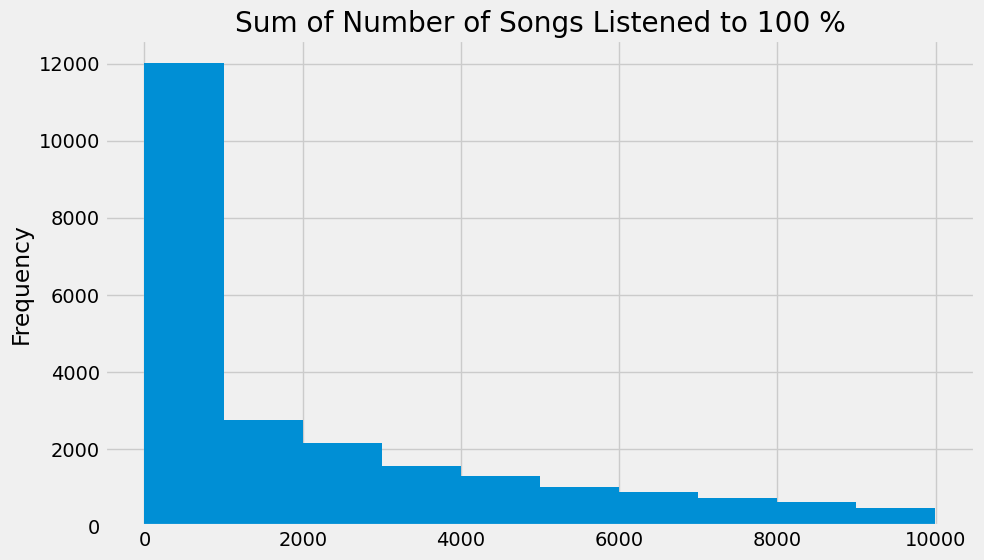

In [111]:
# Visualize distribution of a feature
# feature_matrix['SUM(logs.num_100)']: Selects the column representing the sum of the number of songs a user listened to 100% (i.e., to completion)
# feature_matrix['SUM(logs.num_100)'] < 10000: Filters the data to include only users with a sum less than 10,000, removing extreme outliers for clearer visualization.

feature_matrix.loc[feature_matrix['SUM(logs.num_100)'] < 10000, 'SUM(logs.num_100)'].plot.hist();
plt.title('Sum of Number of Songs Listened to 100 %');

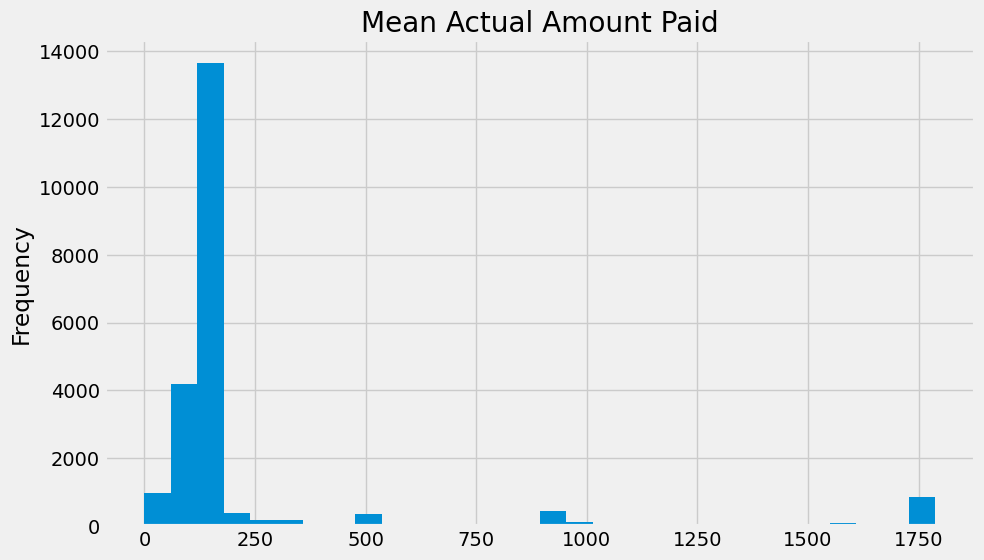

In [124]:
feature_matrix['MEAN(transactions.actual_amount_paid)'].plot.hist(bins = 30);
plt.title('Mean Actual Amount Paid');


In [125]:
feature_matrix['MEAN(transactions.actual_amount_paid)'].describe()

count    21861.000000
mean       242.840201
std        366.589078
min          0.000000
25%        124.166667
50%        149.000000
75%        149.000000
max       1788.000000
Name: MEAN(transactions.actual_amount_paid), dtype: float64

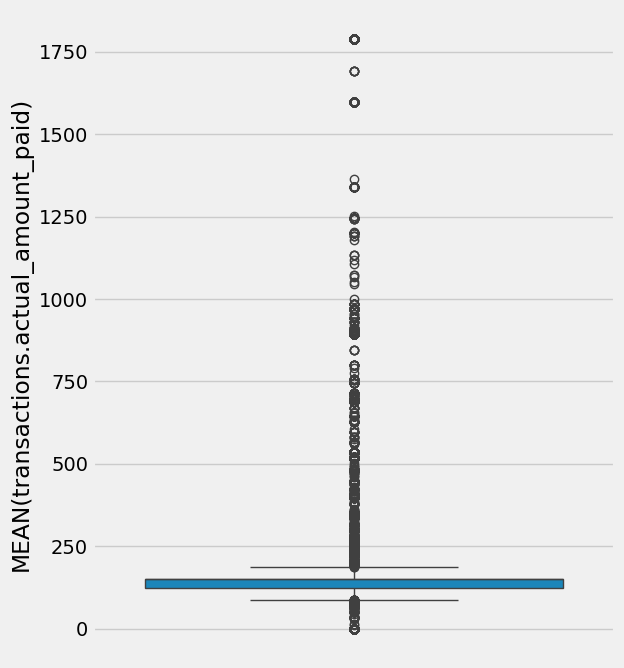

In [129]:
plt.figure(figsize = (6, 8))
sns.boxplot(y = feature_matrix['MEAN(transactions.actual_amount_paid)']);

In [ ]:
feature_defs = ft.load_features('./data/churn/features.txt')
print(f'There are {len(feature_defs)} features.')

# Conclusions

Automated feature engineering is a significant improvement over manual feature engineering in terms of both time and modeling performance. In this notebook, we implemented an automated feature engineering workflow with Featuretools for the customer churn problem. Given customer data and label times, we can now calculate a feature matrix with several hundred relevant features for predicting customer churn while ensuring that our features are made with valid data for each cutoff time.

Along the way, we implemented a number of Featuretools concepts:

1. An entityset and entities
2. Relationships between entities
3. Cutoff times
4. Feature primitives
5. Custom primitives
6. Deep feature synthesis

These concepts will serve us well in future machine learning projects that we can tackle with automated feature engineering.

## Next Steps

Although we often hear that "data is the fuel of machine learning", data is not exactly a fuel but more like crude oil. _Features_ are the refined product that we feed into a machine learning model to make accurate predictions. After performing prediction engineering and automated feature engineering, the next step is to use these features in a predictive model to estimate the _label_ using the _features_.

Generating hundreds of features automatically is impressive, but if those features cannot allow a model to learn our prediction problem then they are not mcuch help! The next step is to use our features and labeled historical examples to train a machine learning model to make predictions of customer churn. We'll make sure to test our model using a hold-out testing set to estimate performance on new data. Then, after validating our model, we can use it on new examples by passing the data through the feature engineering process.


If you want to see how to parallelize feature engineering in Spark, see the `Feature Engineering on Spark` notebook. Otherwise, the next notebook is `Modeling`, where we develop a machine learning model to predict churn using the historical labeled examples and the automatically engineered features.

## Feature Validation and Simple Model Example

After generating features, always validate them before modeling:

- Check for missing values (NaNs) and impute or drop as needed.
- Review feature distributions for outliers or unexpected values.
- Optionally, use a simple model (e.g., logistic regression) to check predictive signal.

```python
# Check for missing values
missing = feature_matrix.isnull().sum().sort_values(ascending=False)
print("Missing values per feature:\n", missing[missing > 0])

# Simple model example
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Drop rows with NaN for simplicity (or use imputation)
X = feature_matrix.dropna()
y = cutoff_times.loc[X.index, 'label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
preds = model.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, preds))
```


### How to Validate and Explore Hundreds of Features Efficiently
- **Missing values:** Use `missing.head(20)` to see the top features with missing data. Visualize with a bar plot for the most-missing features.
- **Distributions:** Use `.describe()` on the DataFrame for summary stats. For outliers, plot a sample of features (e.g., top 10 by variance or missingness).
- **Automated EDA:** Use libraries like `pandas_profiling` or `sweetviz` for automated reports on all features.
- **Correlation:** Use `feature_matrix.corr()` to find highly correlated features. Visualize with a heatmap for the top N features.
- **Feature importance:** After fitting a model, use `model.coef_` (for linear models) or `model.feature_importances_` (for tree models) to rank features.
- **Dimensionality reduction:** Use PCA or UMAP to visualize high-dimensional data and spot outliers or clusters.
- **Iterative approach:** Focus on the most important or problematic features first, then refine.

## Performance and Reproducibility Tips

- For large datasets, use Dask with Featuretools for parallel/distributed computation: see [Featuretools Dask docs](https://featuretools.alteryx.com/en/stable/guides/parallel.html).
- Adjust `chunk_size` and `n_jobs` in `ft.dfs` for optimal performance on your hardware.
- Monitor memory and CPU usage with tools like `psutil` or JupyterLab's resource monitor.
- Use a virtual environment (venv, conda, or poetry) for reproducibility. Example conda environment:

```yaml
name: featuretools-churn
channels:
  - conda-forge
dependencies:
  - python>=3.10
  - pandas>=2.2.0
  - featuretools>=1.30.0
  - dask>=2024.4.0
  - distributed>=2024.4.0
  - matplotlib>=3.8.0
  - seaborn>=0.13.0
  - scikit-learn
```

- Pin package versions in `requirements.txt` or `environment.yml` for consistent results.


## References (2025)

- [Featuretools Documentation](https://featuretools.alteryx.com/en/stable/)
- [Featuretools Dask Parallelization Guide](https://featuretools.alteryx.com/en/stable/guides/parallel.html)
- [Featuretools Custom Primitives](https://featuretools.alteryx.com/en/stable/guides/primitives.html)
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Scikit-learn Documentation](https://scikit-learn.org/stable/)
